In [1]:
# duckdb lets us run actual SQL (CTEs, window functions, etc.) straight on a pandas df
# -q just keeps pip from dumping a wall of text into the notebook
!pip install -q duckdb pandas matplotlib seaborn
print("done installing")


done installing


In [2]:
import duckdb
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

np.random.seed(42)  # fixed seed so the fake data doesn't change every time I rerun this

# faking ~15k orders from 2k customers spread across a bit over a year
n_orders = 15000
n_customers = 2000

start_date = datetime(2025, 1, 1)
end_date = datetime(2026, 2, 28)
date_range = (end_date - start_date).days

customer_ids = np.random.randint(1001, 1001 + n_customers, size=n_orders)

# exponential spacing so later dates get more orders, roughly mimics a growing business
order_dates = [start_date + timedelta(days=int(np.random.exponential(scale=date_range / 2) % date_range)) for _ in range(n_orders)]

# gamma distribution gives a realistic right-skewed spend (lots of small orders, few big ones)
order_amounts = np.round(np.random.gamma(shape=3.0, scale=35.0, size=n_orders) + 10.0, 2)

raw_data = pd.DataFrame({
    "order_id": [f"ORD-{i+100000}" for i in range(n_orders)],
    "customer_id": customer_ids,
    "order_date": pd.to_datetime(order_dates),
    "order_amount": order_amounts
}).sort_values("order_date").reset_index(drop=True)

# pushing this into duckdb so I can write real SQL instead of chaining pandas methods
con = duckdb.connect(database=":memory:")
con.register("raw_orders", raw_data)
con.execute("""
    CREATE TABLE orders AS
    SELECT
        order_id,
        customer_id,
        CAST(order_date AS DATE) AS order_date,
        CAST(order_amount AS DECIMAL(10,2)) AS order_amount
    FROM raw_orders;
""")

print(f"orders table has {con.execute('SELECT COUNT(*) FROM orders').fetchone()[0]} rows")
con.execute("SELECT * FROM orders LIMIT 5").fetchdf()


orders table has 15000 rows


,order_id,customer_id,order_date,order_amount
0,ORD-109644,1787,2025-01-01,76.22
1,ORD-111828,1788,2025-01-01,212.43
2,ORD-106551,2754,2025-01-01,41.94
3,ORD-101510,2901,2025-01-01,111.39
4,ORD-100118,1720,2025-01-01,116.94


In [3]:
# monthly cohort retention: group customers by the month of their first order,
# then see what % of each cohort is still buying in the months after that

cohort_sql = """
WITH customer_cohort AS (
    -- a customer's cohort = the month of their very first order
    SELECT
        customer_id,
        MIN(DATE_TRUNC('month', order_date)) AS cohort_month
    FROM orders
    GROUP BY customer_id
),
customer_orders AS (
    -- tag every order with the customer's cohort month
    SELECT
        o.customer_id,
        c.cohort_month,
        DATE_TRUNC('month', o.order_date) AS order_month
    FROM orders o
    JOIN customer_cohort c ON o.customer_id = c.customer_id
),
cohort_index AS (
    -- how many months out from signup is this order? 0 = the signup month itself
    SELECT
        cohort_month,
        order_month,
        (EXTRACT(YEAR FROM order_month) - EXTRACT(YEAR FROM cohort_month)) * 12 +
        (EXTRACT(MONTH FROM order_month) - EXTRACT(MONTH FROM cohort_month)) AS period_index,
        customer_id
    FROM customer_orders
),
cohort_counts AS (
    SELECT
        cohort_month,
        period_index,
        COUNT(DISTINCT customer_id) AS active_customers
    FROM cohort_index
    GROUP BY cohort_month, period_index
)
SELECT
    CAST(cohort_month AS VARCHAR) AS cohort_month,
    period_index,
    active_customers,
    -- retention rate vs. period 0 (the cohort's first month)
    ROUND(
        CAST(active_customers AS FLOAT) /
        FIRST_VALUE(active_customers) OVER (
            PARTITION BY cohort_month ORDER BY period_index
        ) * 100, 2
    ) AS retention_rate
FROM cohort_counts
ORDER BY cohort_month, period_index;
"""

cohort_results = con.execute(cohort_sql).fetchdf()
print(f"cohort table built, {len(cohort_results)} rows")
cohort_results.head(10)


cohort table built, 82 rows


,cohort_month,period_index,active_customers,retention_rate
0,2025-01-01,0,1380,100.000000
1,2025-01-01,1,840,60.869999
2,2025-01-01,2,807,58.480000
3,2025-01-01,3,704,51.009998
4,2025-01-01,4,700,50.720001
5,2025-01-01,5,608,44.060001
6,2025-01-01,6,550,39.860001
7,2025-01-01,7,456,33.040001
8,2025-01-01,8,439,31.809999
9,2025-01-01,9,367,26.590000


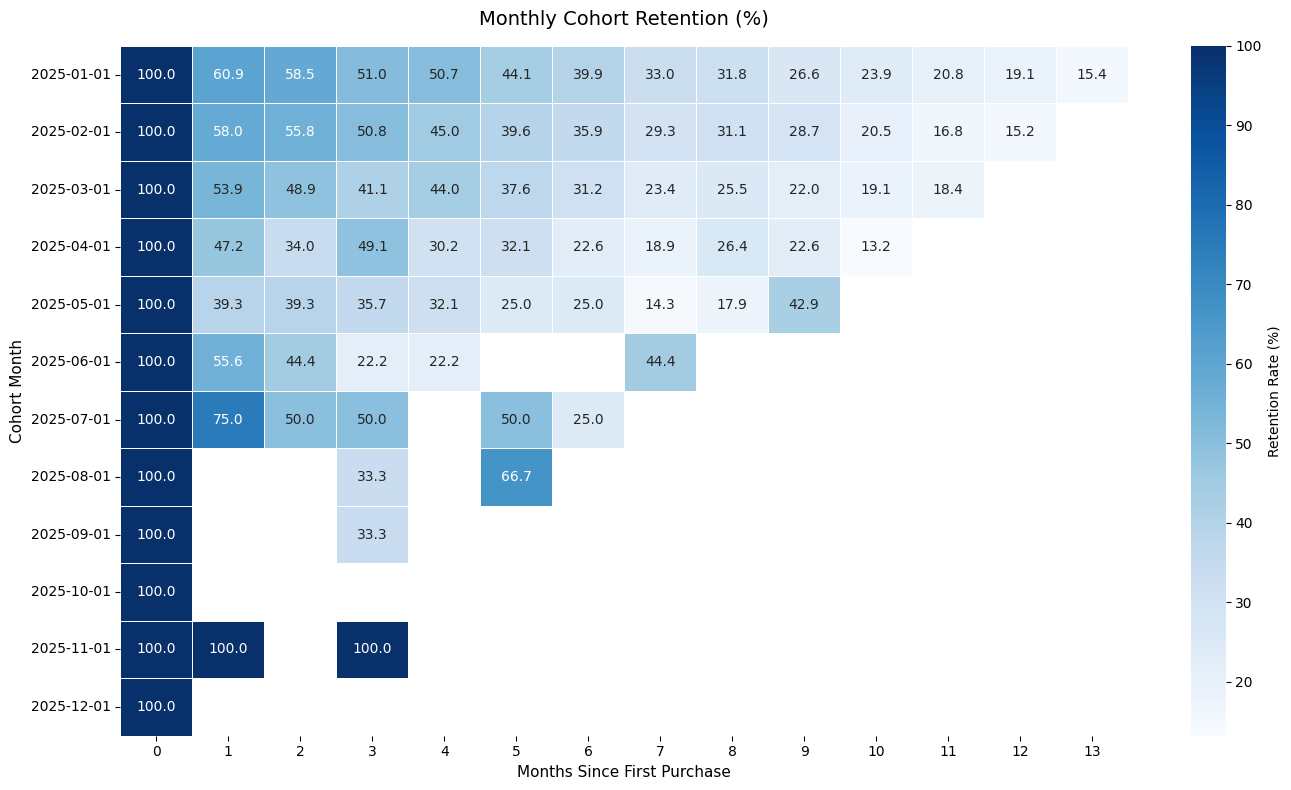

saved as cohort_retention_matrix.png


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# reshape long -> wide so each row is a cohort and each column is a month offset
pivot_df = cohort_results.pivot(
    index="cohort_month",
    columns="period_index",
    values="retention_rate"
)

plt.figure(figsize=(14, 8))
sns.heatmap(
    pivot_df,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={'label': 'Retention Rate (%)'}
)
plt.title("Monthly Cohort Retention (%)", fontsize=14, pad=15)
plt.xlabel("Months Since First Purchase", fontsize=11)
plt.ylabel("Cohort Month", fontsize=11)
plt.tight_layout()
plt.savefig("cohort_retention_matrix.png", dpi=300)
plt.show()
print("saved as cohort_retention_matrix.png")


In [5]:
# RFM segmentation - Recency, Frequency, Monetary
# split customers into quintiles on each metric, then bucket them into rough segments

rfm_sql = """
WITH rfm_base AS (
    SELECT
        customer_id,
        DATE_DIFF('day', MAX(order_date), CAST('2026-03-01' AS DATE)) AS recency_days,
        COUNT(DISTINCT order_id) AS frequency_orders,
        SUM(order_amount) AS monetary_total
    FROM orders
    GROUP BY customer_id
),
rfm_scores AS (
    SELECT
        customer_id,
        recency_days,
        frequency_orders,
        monetary_total,
        -- fewer days since last order is better, so the quintile gets flipped
        6 - NTILE(5) OVER (ORDER BY recency_days ASC) AS r_score,
        NTILE(5) OVER (ORDER BY frequency_orders ASC) AS f_score,
        NTILE(5) OVER (ORDER BY monetary_total ASC) AS m_score
    FROM rfm_base
),
rfm_segmented AS (
    SELECT
        customer_id,
        recency_days,
        frequency_orders,
        monetary_total,
        r_score,
        f_score,
        m_score,
        (r_score + f_score + m_score) / 3.0 AS rfm_average,
        -- these thresholds are a starting point, could be tuned per business
        CASE
            WHEN r_score >= 4 AND f_score >= 4 AND m_score >= 4 THEN 'Champions'
            WHEN r_score >= 3 AND f_score >= 3 THEN 'Loyal Customers'
            WHEN r_score >= 4 AND f_score <= 2 THEN 'Recent Inactive / New'
            WHEN r_score <= 2 AND f_score >= 3 THEN 'At Risk / Churning'
            ELSE 'Lost / Hibernating'
        END AS customer_segment
    FROM rfm_scores
)
SELECT
    customer_segment,
    COUNT(*) AS total_customers,
    ROUND(AVG(recency_days), 1) AS avg_recency_days,
    ROUND(AVG(frequency_orders), 1) AS avg_orders,
    ROUND(AVG(monetary_total), 2) AS avg_customer_spend,
    ROUND(SUM(monetary_total), 2) AS total_segment_revenue
FROM rfm_segmented
GROUP BY customer_segment
ORDER BY total_segment_revenue DESC;
"""

rfm_summary = con.execute(rfm_sql).fetchdf()
print("rfm summary done")
display(rfm_summary)


rfm summary done


,customer_segment,total_customers,avg_recency_days,avg_orders,avg_customer_spend,total_segment_revenue
0,Loyal Customers,505,70.0,8.6,957.99,483786.57
1,Champions,313,38.5,11.0,1309.58,409898.76
2,At Risk / Churning,382,181.4,8.8,1013.32,387086.67
3,Lost / Hibernating,558,185.2,4.6,533.99,297968.29
4,Recent Inactive / New,242,35.4,5.3,607.51,147018.02


In [6]:
# rolling 7/30 day sales plus a running total, all done with window functions

moving_avg_sql = """
WITH daily_revenue AS (
    SELECT
        order_date,
        COUNT(order_id) AS total_orders,
        SUM(order_amount) AS daily_sales
    FROM orders
    GROUP BY order_date
)
SELECT
    order_date,
    daily_sales,
    ROUND(AVG(daily_sales) OVER (
        ORDER BY order_date
        ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
    ), 2) AS rolling_7d_sales,
    ROUND(AVG(daily_sales) OVER (
        ORDER BY order_date
        ROWS BETWEEN 29 PRECEDING AND CURRENT ROW
    ), 2) AS rolling_30d_sales,
    ROUND(SUM(daily_sales) OVER (
        ORDER BY order_date
        ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
    ), 2) AS cumulative_revenue
FROM daily_revenue
ORDER BY order_date;
"""

moving_avg_results = con.execute(moving_avg_sql).fetchdf()
print("moving average table ready")
moving_avg_results.tail(10)


moving average table ready


,order_date,daily_sales,rolling_7d_sales,rolling_30d_sales,cumulative_revenue
413,2026-02-18,754.08,1332.36,1406.20,1713221.71
414,2026-02-19,1292.99,1250.78,1417.44,1714514.70
415,2026-02-20,1151.54,1244.65,1398.59,1715666.24
416,2026-02-21,1398.11,1267.12,1388.93,1717064.35
417,2026-02-22,1855.87,1286.39,1399.03,1718920.22
418,2026-02-23,2070.88,1399.36,1429.50,1720991.10
419,2026-02-24,2161.16,1526.38,1454.14,1723152.26
420,2026-02-25,956.10,1555.24,1440.62,1724108.36
421,2026-02-26,1058.44,1521.73,1437.06,1725166.80
422,2026-02-27,591.51,1441.72,1421.37,1725758.31


In [7]:
# dropping the sql + results to disk so they can sit in the repo as standalone files
sql_scripts = {
    "01_cohort_retention.sql": cohort_sql,
    "02_rfm_segmentation.sql": rfm_sql,
    "03_moving_averages_kpis.sql": moving_avg_sql
}

for filename, script_content in sql_scripts.items():
    with open(filename, "w") as f:
        f.write(script_content.strip())
    print("wrote", filename)

cohort_results.to_csv("cohort_retention_data.csv", index=False)
rfm_summary.to_csv("rfm_segmentation_summary.csv", index=False)
moving_avg_results.to_csv("rolling_revenue_kpis.csv", index=False)
print("csvs exported")


wrote 01_cohort_retention.sql
wrote 02_rfm_segmentation.sql
wrote 03_moving_averages_kpis.sql
csvs exported
